In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [2]:
df = yf.download(tickers=['AAPL'],period='1mo',interval='5m');

[*********************100%***********************]  1 of 1 completed


In [3]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Datetime,,,,,
2026-05-04 13:30:00+00:00,277.050110,280.630005,276.720001,279.654999,3283368
2026-05-04 13:35:00+00:00,277.160095,277.459991,276.165009,277.128296,1016492
2026-05-04 13:40:00+00:00,276.779999,277.170013,276.160004,277.160004,860936
2026-05-04 13:45:00+00:00,277.558411,277.608002,276.510010,276.790009,771532
2026-05-04 13:50:00+00:00,276.179993,277.670013,276.049988,277.575012,1071292
...,...,...,...,...,...
2026-06-02 15:45:00+00:00,312.829987,312.890015,312.450012,312.880005,279790
2026-06-02 15:50:00+00:00,312.720001,313.149994,312.609985,312.825012,415883


In [4]:
n = 10
df['ROC'] = (df['Close'] - df['Close'].shift(n)) / df['Close'].shift(n) * 100

# A. Rate of Change (ROC)

Simple momentum.

ROC= ((Closeₜ - close(ₜ-n))/close(ₜ-n)) x 100

Positive → bullish momentum

Negative → bearish momentum

In [5]:
df['ROC']

Datetime
2026-05-04 13:30:00+00:00         NaN
2026-05-04 13:35:00+00:00         NaN
2026-05-04 13:40:00+00:00         NaN
2026-05-04 13:45:00+00:00         NaN
2026-05-04 13:50:00+00:00         NaN
                               ...   
2026-06-02 15:45:00+00:00    0.747150
2026-06-02 15:50:00+00:00    0.620996
2026-06-02 15:55:00+00:00    0.147450
2026-06-02 16:00:00+00:00    0.251624
2026-06-02 16:05:00+00:00    0.163370
Name: ROC, Length: 1592, dtype: float64

In [6]:
max_roc = df['ROC'].max()
min_roc = df['ROC'].min()
print(f"Maximum ROC: {max_roc}")
print(f"Minimum ROC: {min_roc}")

Maximum ROC: 2.4620504450867804
Minimum ROC: -1.2036125854209205


In [7]:
df.describe()

Price,Close,High,Low,Open,Volume,ROC
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
count,1592.000000,1592.000000,1592.000000,1592.000000,1.592000e+03,1582.000000
mean,298.749027,299.009220,298.460776,298.727385,4.475333e+05,0.079076
std,9.939997,9.933411,9.956857,9.943142,7.104110e+05,0.433710
min,275.049988,275.760010,274.860107,275.040009,0.000000e+00,-1.203613
25%,292.609985,292.788757,292.399994,292.603737,2.276912e+05,-0.183968
50%,298.750000,299.024994,298.500000,298.720001,3.130245e+05,0.048363
75%,308.982414,309.269989,308.619995,308.978752,4.599158e+05,0.281373
max,314.351105,315.000000,313.720001,314.399994,1.631315e+07,2.462050


In [8]:
df.isnull().sum()

Price   Ticker
Close   AAPL       0
High    AAPL       0
Low     AAPL       0
Open    AAPL       0
Volume  AAPL       0
ROC               10
dtype: int64

In [9]:
df.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL'),
            (   'ROC',     '')],
           names=['Price', 'Ticker'])

In [10]:
numeric_columns = ['Open', 'High', 'Low', 'Close', 'Volume']

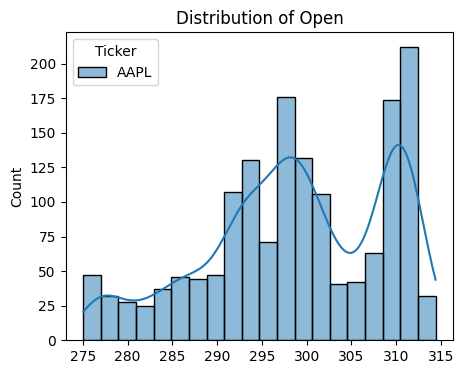

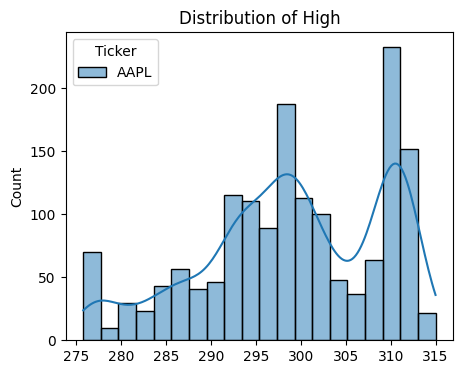

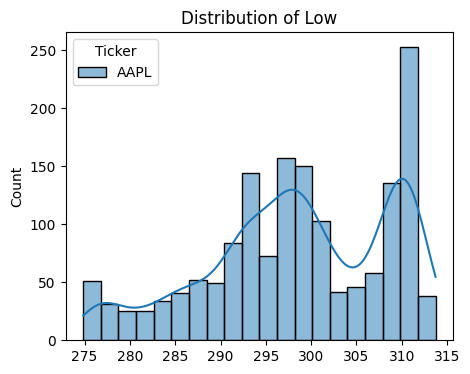

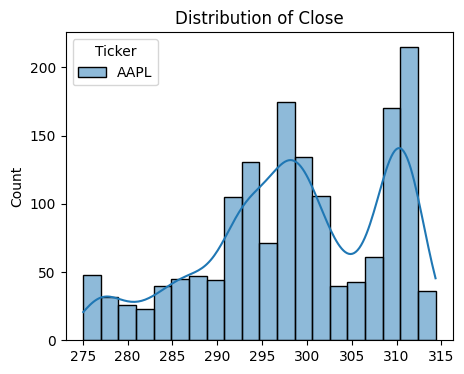

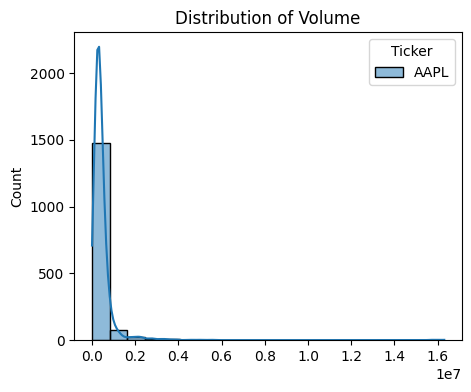

In [11]:
for col in numeric_columns:
  plt.figure(figsize=(5, 4))
  sns.histplot(df[col], kde=True, bins=20)
  #kde -> kernel density estimation
  plt.title(f'Distribution of {col}')
  plt.show()


In [12]:
df.columns = [col[0] if col[1]=='' else f'{col[0]}_{col[1]}' for col in df.columns]

print(df.columns)

Index(['Close_AAPL', 'High_AAPL', 'Low_AAPL', 'Open_AAPL', 'Volume_AAPL',
       'ROC'],
      dtype='str')


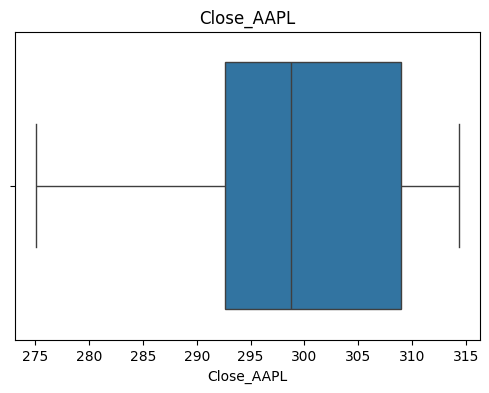

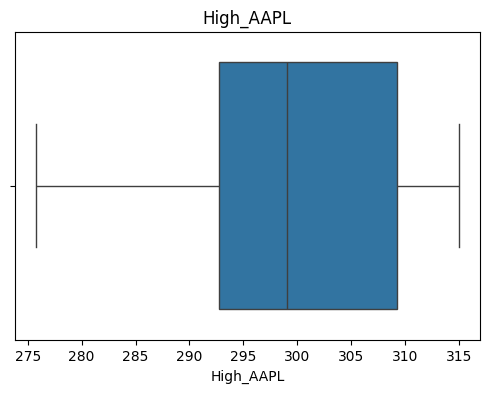

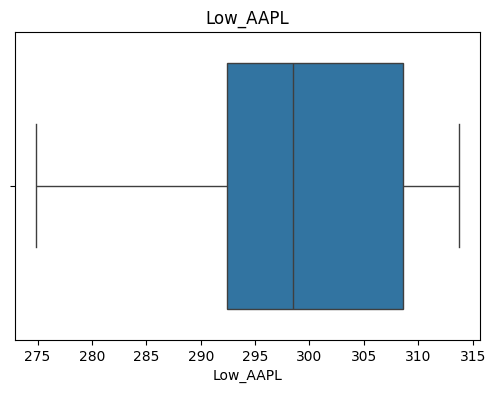

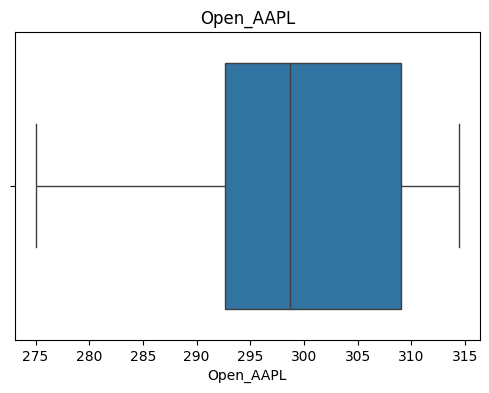

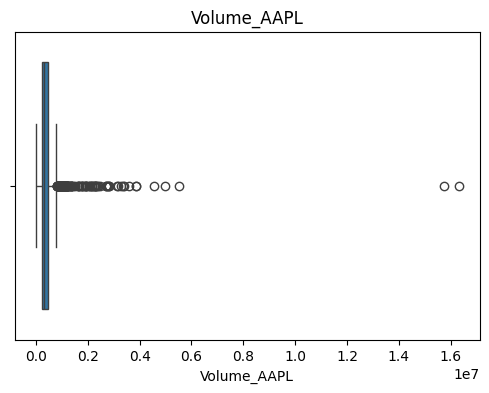

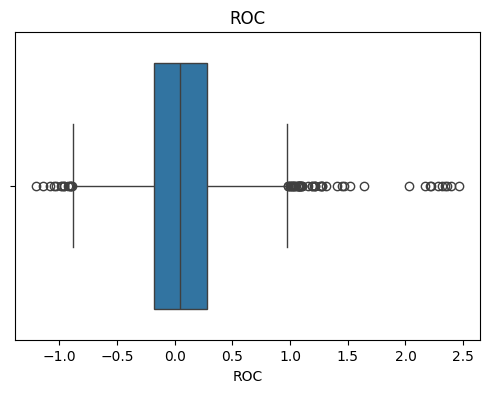

In [13]:
numeric_columns = df.select_dtypes(include='number').columns

for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col].dropna())
    plt.title(col)
    plt.show()

<Axes: >

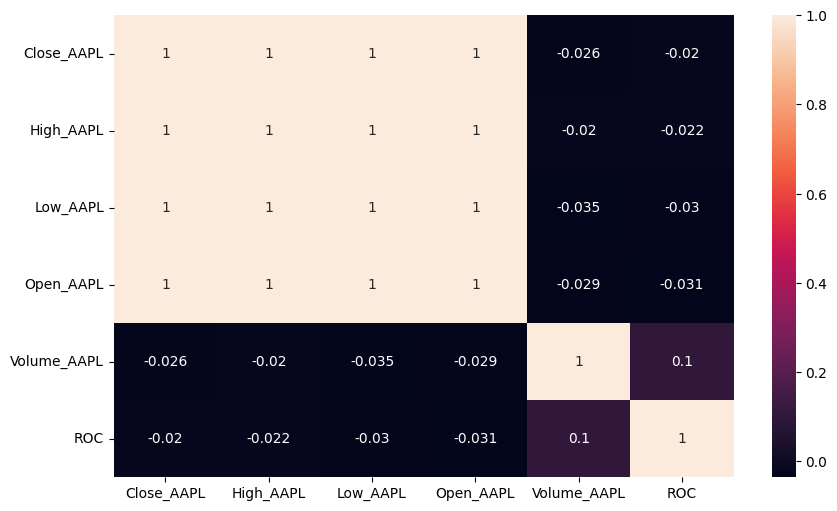

In [14]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True)

# DATA CLEANING AND PREPROCESSING

In [15]:
df_cleaned = df.copy()

In [16]:
df_cleaned.head()

,Close_AAPL,High_AAPL,Low_AAPL,Open_AAPL,Volume_AAPL,ROC
Datetime,,,,,,
2026-05-04 13:30:00+00:00,277.050110,280.630005,276.720001,279.654999,3283368,NaN
2026-05-04 13:35:00+00:00,277.160095,277.459991,276.165009,277.128296,1016492,NaN
2026-05-04 13:40:00+00:00,276.779999,277.170013,276.160004,277.160004,860936,NaN
2026-05-04 13:45:00+00:00,277.558411,277.608002,276.510010,276.790009,771532,NaN
2026-05-04 13:50:00+00:00,276.179993,277.670013,276.049988,277.575012,1071292,NaN


In [17]:
df_cleaned.shape

(1592, 6)

In [18]:
df_cleaned.drop_duplicates(inplace=True)
#or
df2 = df_cleaned.drop_duplicates()

In [19]:
df_cleaned.shape

(1592, 6)

In [20]:
df_cleaned.isnull().sum()

Close_AAPL      0
High_AAPL       0
Low_AAPL        0
Open_AAPL       0
Volume_AAPL     0
ROC            10
dtype: int64

In [21]:
df_cleaned.dtypes

Close_AAPL     float64
High_AAPL      float64
Low_AAPL       float64
Open_AAPL      float64
Volume_AAPL      int64
ROC            float64
dtype: object

# LEBEL ENCODING 
it is used to change object into integer. 
EX- male and female -> 1 and 0

df_cleaned['sex'].value_counts()

df_cleaned['sex'] = df_cleaned['sex'].map({"male":1, "female":0})

df_cleaned.rename(columns={
    'sex' : 'is_male'
},inplace = True)

# ONE-HOT ENCODING

It is used to change object having more than two value into integer.

EX- northeast, northwest, southeast, southwest

df_cleaned['region'].value_counts()

df_cleaned = pd.get_dummies(df_cleaned,columns = ['region'], drop_first = True)

In [22]:
df_cleaned = df_cleaned.astype(int)

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer.Replace or remove non-finite values or cast to an integer typethat supports these values (e.g. 'Int64')

# FEATURE ENGINEERING AND EXTRACTION

<Axes: xlabel='Close_AAPL', ylabel='Count'>

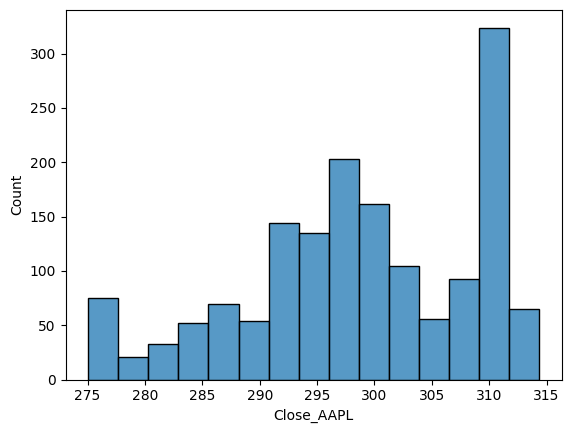

In [23]:
sns.histplot(df['Close_AAPL'])

# ques: HOW TO CUT COLUMN 

df_cleaned['bmi_category'] = pd.cut(

    df_cleaned['bmi'],

    bins = [0,18.5,24.9,29.9,float('inf')],
    
    labels = ['Underweight','Normal','Overweight','Obese']
)

NOW USE ONE-HOT ENCODING TO MAKE MULTIPLE ATTRIBUTES

In [24]:
df_cleaned.head()

,Close_AAPL,High_AAPL,Low_AAPL,Open_AAPL,Volume_AAPL,ROC
Datetime,,,,,,
2026-05-04 13:30:00+00:00,277.050110,280.630005,276.720001,279.654999,3283368,NaN
2026-05-04 13:35:00+00:00,277.160095,277.459991,276.165009,277.128296,1016492,NaN
2026-05-04 13:40:00+00:00,276.779999,277.170013,276.160004,277.160004,860936,NaN
2026-05-04 13:45:00+00:00,277.558411,277.608002,276.510010,276.790009,771532,NaN
2026-05-04 13:50:00+00:00,276.179993,277.670013,276.049988,277.575012,1071292,NaN


In [25]:
df_cleaned.columns

Index(['Close_AAPL', 'High_AAPL', 'Low_AAPL', 'Open_AAPL', 'Volume_AAPL',
       'ROC'],
      dtype='str')

In [26]:
from sklearn.preprocessing import StandardScaler
cols = ['Open_AAPL', 'High_AAPL', 'Low_AAPL', 'Close_AAPL']
scaler = StandardScaler()

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [27]:
df_cleaned.head()

,Close_AAPL,High_AAPL,Low_AAPL,Open_AAPL,Volume_AAPL,ROC
Datetime,,,,,,
2026-05-04 13:30:00+00:00,-2.183676,-1.850824,-2.184184,-1.918747,3283368,NaN
2026-05-04 13:35:00+00:00,-2.172608,-2.170050,-2.239941,-2.172942,1016492,NaN
2026-05-04 13:40:00+00:00,-2.210859,-2.199252,-2.240444,-2.169753,860936,NaN
2026-05-04 13:45:00+00:00,-2.132523,-2.155145,-2.205281,-2.206975,771532,NaN
2026-05-04 13:50:00+00:00,-2.271241,-2.148901,-2.251497,-2.128001,1071292,NaN


In [30]:
from scipy.stats import pearsonr 

#--------------------------------
# Pearson correlation calculation
#--------------------------------

# list of features to check against target

selected_features = ['Close_AAPL', 'High_AAPL', 'Low_AAPL', 'Open_AAPL']

correlations = {
    feature : pearsonr(df_cleaned[feature], df_cleaned['Volume_AAPL'])[0] 
    for feature in selected_features
}

correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature','Pearson_Correlation'])
correlation_df.sort_values(by='Pearson_Correlation', ascending=False)


,Feature,Pearson_Correlation
1,High_AAPL,-0.019981
0,Close_AAPL,-0.026374
3,Open_AAPL,-0.029462
2,Low_AAPL,-0.035085


# CHI SQUERE TEST
used for compering chategorical data <-> chategorical data

cat_features = []

from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)

chi2_results = {}

for col in cat_features:

    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])

    chi2_stat, p_val, _, _ = chi2_contingency(contingency)

    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'

    chi2_results[col] = {

        'chi2_statistic': chi2_stat,

        'p_value': p_val,

        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T

chi2_df = chi2_df.sort_values(by='p_value')

chi2_df